# Cálculo de derivadas parciales mediante diferencias finitas

## Objetivo

En este notebook se estudia el cálculo numérico de **derivadas parciales** usando diferencias finitas.  
Se incluyen varios aspectos didácticos:

- aproximaciones para $$\frac{\partial u}{\partial x}$$ y $$\frac{\partial u}{\partial y}$$,
- fórmulas centradas y descentradas,
- derivadas parciales de segundo orden,
- derivada mixta $$\frac{\partial^2 u}{\partial x \partial y}$$,
- comparación con derivadas exactas,
- análisis del error numérico,
- aplicación sobre una malla bidimensional.

## Función de prueba

Trabajaremos con la función:

$$
u(x,y)=e^x \sin y + x^2 y
$$

porque permite calcular de forma exacta varias derivadas parciales y compararlas con las aproximaciones numéricas.

## Derivadas exactas

Primera derivada respecto a $$x$$:

$$
\frac{\partial u}{\partial x}=e^x \sin y + 2xy
$$

Primera derivada respecto a $$y$$:

$$
\frac{\partial u}{\partial y}=e^x \cos y + x^2
$$

Segunda derivada respecto a $$x$$:

$$
\frac{\partial^2 u}{\partial x^2}=e^x \sin y + 2y
$$

Segunda derivada respecto a $$y$$:

$$
\frac{\partial^2 u}{\partial y^2}=-e^x \sin y
$$

Derivada mixta:

$$
\frac{\partial^2 u}{\partial x \partial y}=e^x \cos y + 2x
$$

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Definición de la función y de sus derivadas exactas

In [2]:
def u(x, y):
    return np.exp(x) * np.sin(y) + x**2 * y

def ux_exacta(x, y):
    return np.exp(x) * np.sin(y) + 2.0 * x * y

def uy_exacta(x, y):
    return np.exp(x) * np.cos(y) + x**2

def uxx_exacta(x, y):
    return np.exp(x) * np.sin(y) + 2.0 * y

def uyy_exacta(x, y):
    return -np.exp(x) * np.sin(y)

def uxy_exacta(x, y):
    return np.exp(x) * np.cos(y) + 2.0 * x

## 3. Punto de evaluación y tamaños de paso

Tomaremos el punto:

$$
(x_0,y_0)=(1,\,0.5)
$$

y ensayaremos varios tamaños de paso uniformes:

$$
h_x = h_y = h
$$

In [3]:
x0 = 1.0
y0 = 0.5
hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])

print("x0 =", x0)
print("y0 =", y0)
print("h =", hs)

x0 = 1.0
y0 = 0.5
h = [0.2    0.1    0.05   0.025  0.0125]


# Parte A. Primeras derivadas parciales

## 4. Aproximaciones para $$\frac{\partial u}{\partial x}$$

### Diferencia hacia adelante

$$
\frac{\partial u}{\partial x}(x,y)
\approx
\frac{u(x+h,y)-u(x,y)}{h}
\qquad O(h)
$$

### Diferencia hacia atrás

$$
\frac{\partial u}{\partial x}(x,y)
\approx
\frac{u(x,y)-u(x-h,y)}{h}
\qquad O(h)
$$

### Diferencia centrada

$$
\frac{\partial u}{\partial x}(x,y)
\approx
\frac{u(x+h,y)-u(x-h,y)}{2h}
\qquad O(h^2)
$$

In [4]:
def ux_forward_o1(u, x, y, h):
    return (u(x + h, y) - u(x, y)) / h

def ux_backward_o1(u, x, y, h):
    return (u(x, y) - u(x - h, y)) / h

def ux_center_o2(u, x, y, h):
    return (u(x + h, y) - u(x - h, y)) / (2.0 * h)

## 5. Aproximaciones para $$\frac{\partial u}{\partial y}$$

### Diferencia hacia adelante

$$
\frac{\partial u}{\partial y}(x,y)
\approx
\frac{u(x,y+h)-u(x,y)}{h}
\qquad O(h)
$$

### Diferencia hacia atrás

$$
\frac{\partial u}{\partial y}(x,y)
\approx
\frac{u(x,y)-u(x,y-h)}{h}
\qquad O(h)
$$

### Diferencia centrada

$$
\frac{\partial u}{\partial y}(x,y)
\approx
\frac{u(x,y+h)-u(x,y-h)}{2h}
\qquad O(h^2)
$$

In [5]:
def uy_forward_o1(u, x, y, h):
    return (u(x, y + h) - u(x, y)) / h

def uy_backward_o1(u, x, y, h):
    return (u(x, y) - u(x, y - h)) / h

def uy_center_o2(u, x, y, h):
    return (u(x, y + h) - u(x, y - h)) / (2.0 * h)

## 6. Comparación numérica para las primeras derivadas parciales

In [6]:
ux_ex = ux_exacta(x0, y0)
uy_ex = uy_exacta(x0, y0)

filas_prim = []
for h in hs:
    ux_f = ux_forward_o1(u, x0, y0, h)
    ux_b = ux_backward_o1(u, x0, y0, h)
    ux_c = ux_center_o2(u, x0, y0, h)

    uy_f = uy_forward_o1(u, x0, y0, h)
    uy_b = uy_backward_o1(u, x0, y0, h)
    uy_c = uy_center_o2(u, x0, y0, h)

    filas_prim.append({
        "h": h,
        "ux exacta": ux_ex,
        "ux adelante": ux_f,
        "err ux adelante": abs(ux_f - ux_ex),
        "ux atrás": ux_b,
        "err ux atrás": abs(ux_b - ux_ex),
        "ux centrada": ux_c,
        "err ux centrada": abs(ux_c - ux_ex),
        "uy exacta": uy_ex,
        "uy adelante": uy_f,
        "err uy adelante": abs(uy_f - uy_ex),
        "uy atrás": uy_b,
        "err uy atrás": abs(uy_b - uy_ex),
        "uy centrada": uy_c,
        "err uy centrada": abs(uy_c - uy_ex),
    })

df_prim = pd.DataFrame(filas_prim)
df_prim

,h,ux exacta,ux adelante,err ux adelante,ux atrás,err ux atrás,ux centrada,err ux centrada,uy exacta,uy adelante,err uy adelante,uy atrás,err uy atrás,uy centrada,err uy centrada
0,0.2000,2.303214,2.542676,0.239462,2.081163,0.222051,2.311919,0.008705,3.385517,3.239758,0.145759,3.499533,0.114016,3.369645,0.015872
1,0.1000,2.303214,2.420602,0.117388,2.190172,0.113042,2.305387,0.002173,3.385517,3.316436,0.069080,3.446649,0.061133,3.381543,0.003974
2,0.0500,2.303214,2.361344,0.058130,2.246170,0.057044,2.303757,0.000543,3.385517,3.351949,0.033567,3.417096,0.031580,3.384523,0.000994
3,0.0250,2.303214,2.332141,0.028927,2.274558,0.028655,2.303349,0.000136,3.385517,3.368979,0.016538,3.401558,0.016041,3.385268,0.000248
4,0.0125,2.303214,2.317643,0.014429,2.288852,0.014361,2.303248,0.000034,3.385517,3.377310,0.008207,3.393600,0.008083,3.385455,0.000062


## 7. Error de las primeras derivadas parciales

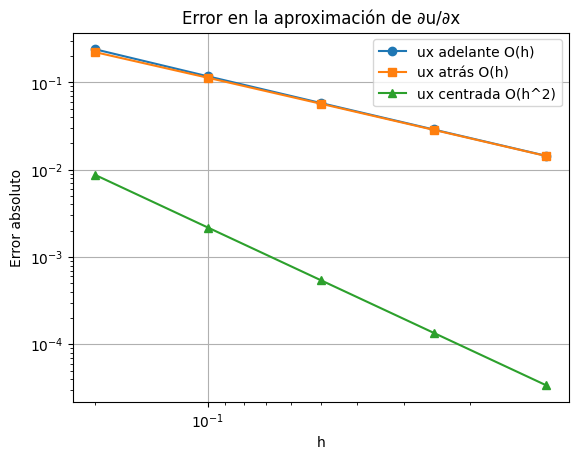

In [7]:
err_ux_f = [abs(ux_forward_o1(u, x0, y0, h) - ux_ex) for h in hs]
err_ux_b = [abs(ux_backward_o1(u, x0, y0, h) - ux_ex) for h in hs]
err_ux_c = [abs(ux_center_o2(u, x0, y0, h) - ux_ex) for h in hs]

plt.loglog(hs, err_ux_f, marker='o', label='ux adelante O(h)')
plt.loglog(hs, err_ux_b, marker='s', label='ux atrás O(h)')
plt.loglog(hs, err_ux_c, marker='^', label='ux centrada O(h^2)')
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en la aproximación de ∂u/∂x")
plt.legend()
plt.grid(True)
plt.show()

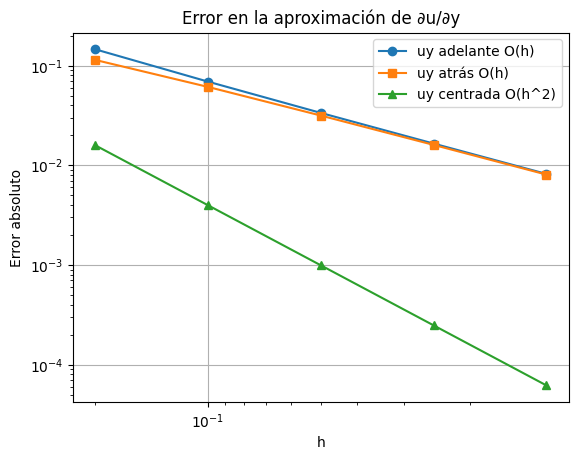

In [8]:
err_uy_f = [abs(uy_forward_o1(u, x0, y0, h) - uy_ex) for h in hs]
err_uy_b = [abs(uy_backward_o1(u, x0, y0, h) - uy_ex) for h in hs]
err_uy_c = [abs(uy_center_o2(u, x0, y0, h) - uy_ex) for h in hs]

plt.loglog(hs, err_uy_f, marker='o', label='uy adelante O(h)')
plt.loglog(hs, err_uy_b, marker='s', label='uy atrás O(h)')
plt.loglog(hs, err_uy_c, marker='^', label='uy centrada O(h^2)')
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en la aproximación de ∂u/∂y")
plt.legend()
plt.grid(True)
plt.show()

# Parte B. Segundas derivadas parciales

## 8. Segunda derivada respecto a $$x$$

La fórmula centrada clásica es:

$$
\frac{\partial^2 u}{\partial x^2}(x,y)
\approx
\frac{u(x+h,y)-2u(x,y)+u(x-h,y)}{h^2}
\qquad O(h^2)
$$

## 9. Segunda derivada respecto a $$y$$

De manera análoga:

$$
\frac{\partial^2 u}{\partial y^2}(x,y)
\approx
\frac{u(x,y+h)-2u(x,y)+u(x,y-h)}{h^2}
\qquad O(h^2)
$$

In [9]:
def uxx_center_o2(u, x, y, h):
    return (u(x + h, y) - 2.0*u(x, y) + u(x - h, y)) / h**2

def uyy_center_o2(u, x, y, h):
    return (u(x, y + h) - 2.0*u(x, y) + u(x, y - h)) / h**2

## 10. Comparación numérica para las segundas derivadas parciales

In [10]:
uxx_ex = uxx_exacta(x0, y0)
uyy_ex = uyy_exacta(x0, y0)

filas_seg = []
for h in hs:
    a1 = uxx_center_o2(u, x0, y0, h)
    a2 = uyy_center_o2(u, x0, y0, h)

    filas_seg.append({
        "h": h,
        "uxx exacta": uxx_ex,
        "uxx numérica": a1,
        "err uxx": abs(a1 - uxx_ex),
        "uyy exacta": uyy_ex,
        "uyy numérica": a2,
        "err uyy": abs(a2 - uyy_ex),
    })

df_seg = pd.DataFrame(filas_seg)
df_seg

,h,uxx exacta,uxx numérica,err uxx,uyy exacta,uyy numérica,err uyy
0,0.2000,2.303214,2.307564,0.004350,-1.303214,-1.298875,0.004338
1,0.1000,2.303214,2.304300,0.001086,-1.303214,-1.302128,0.001086
2,0.0500,2.303214,2.303485,0.000272,-1.303214,-1.302942,0.000271
3,0.0250,2.303214,2.303282,0.000068,-1.303214,-1.303146,0.000068
4,0.0125,2.303214,2.303231,0.000017,-1.303214,-1.303197,0.000017


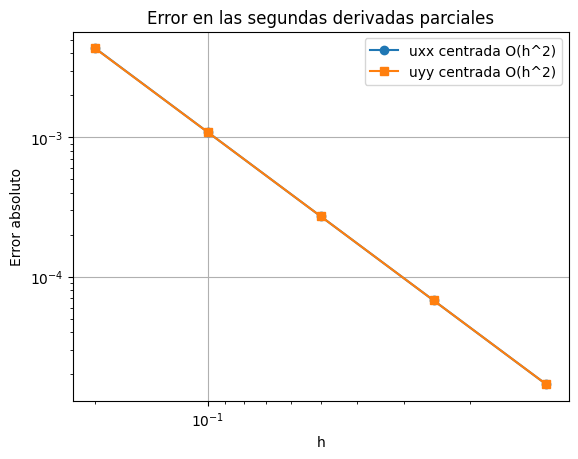

In [11]:
err_uxx = [abs(uxx_center_o2(u, x0, y0, h) - uxx_ex) for h in hs]
err_uyy = [abs(uyy_center_o2(u, x0, y0, h) - uyy_ex) for h in hs]

plt.loglog(hs, err_uxx, marker='o', label='uxx centrada O(h^2)')
plt.loglog(hs, err_uyy, marker='s', label='uyy centrada O(h^2)')
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en las segundas derivadas parciales")
plt.legend()
plt.grid(True)
plt.show()

# Parte C. Derivada parcial mixta

## 11. Aproximación para $$\frac{\partial^2 u}{\partial x \partial y}$$

Una fórmula centrada muy usada es:

$$
\frac{\partial^2 u}{\partial x \partial y}(x,y)
\approx
\frac{
u(x+h,y+h)-u(x+h,y-h)-u(x-h,y+h)+u(x-h,y-h)
}{4h^2}
\qquad O(h^2)
$$

Esta fórmula usa cuatro nodos vecinos alrededor del punto de evaluación.

In [12]:
def uxy_center_o2(u, x, y, h):
    return (
        u(x + h, y + h)
        - u(x + h, y - h)
        - u(x - h, y + h)
        + u(x - h, y - h)
    ) / (4.0 * h**2)

## 12. Comparación numérica para la derivada mixta

In [13]:
uxy_ex = uxy_exacta(x0, y0)

filas_mix = []
for h in hs:
    a = uxy_center_o2(u, x0, y0, h)
    filas_mix.append({
        "h": h,
        "uxy exacta": uxy_ex,
        "uxy numérica": a,
        "error absoluto": abs(a - uxy_ex)
    })

df_mix = pd.DataFrame(filas_mix)
df_mix

,h,uxy exacta,uxy numérica,error absoluto
0,0.2000,4.385517,4.385474,4.240913e-05
1,0.1000,4.385517,4.385514,2.650574e-06
2,0.0500,4.385517,4.385517,1.656608e-07
3,0.0250,4.385517,4.385517,1.035382e-08
4,0.0125,4.385517,4.385517,6.473586e-10


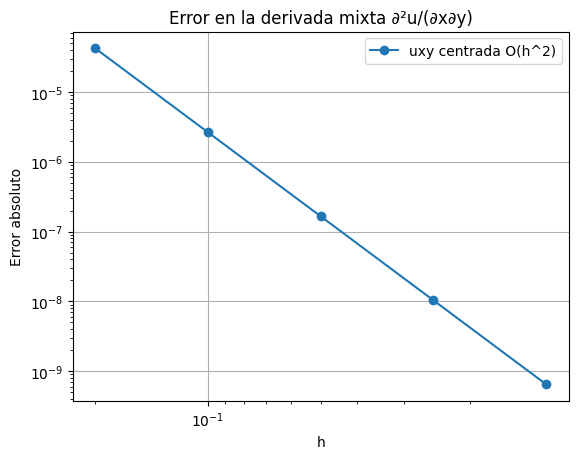

In [14]:
err_uxy = [abs(uxy_center_o2(u, x0, y0, h) - uxy_ex) for h in hs]

plt.loglog(hs, err_uxy, marker='o', label='uxy centrada O(h^2)')
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("Error absoluto")
plt.title("Error en la derivada mixta ∂²u/(∂x∂y)")
plt.legend()
plt.grid(True)
plt.show()

# Parte D. Aplicación sobre una malla bidimensional

## 13. Construcción de una malla uniforme

Consideremos el dominio rectangular:

$$
0 \le x \le 1, \qquad 0 \le y \le 1
$$

y una malla uniforme de $$N_x \times N_y$$ nodos.

In [15]:
Nx = 21
Ny = 21

x = np.linspace(0.0, 1.0, Nx)
y = np.linspace(0.0, 1.0, Ny)

hx = x[1] - x[0]
hy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing='ij')
U = u(X, Y)

print("hx =", hx)
print("hy =", hy)
print("Forma de la malla:", U.shape)

hx = 0.05
hy = 0.05
Forma de la malla: (21, 21)


## 14. Aproximación de $$\frac{\partial u}{\partial x}$$ en nodos interiores

En los nodos interiores de la malla:

$$
\left(\frac{\partial u}{\partial x}\right)_{i,j}
\approx
\frac{u_{i+1,j}-u_{i-1,j}}{2h_x}
$$

## 15. Aproximación de $$\frac{\partial u}{\partial y}$$ en nodos interiores

$$
\left(\frac{\partial u}{\partial y}\right)_{i,j}
\approx
\frac{u_{i,j+1}-u_{i,j-1}}{2h_y}
$$

In [16]:
Ux_num = np.full_like(U, np.nan)
Uy_num = np.full_like(U, np.nan)

for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        Ux_num[i, j] = (U[i+1, j] - U[i-1, j]) / (2.0 * hx)
        Uy_num[i, j] = (U[i, j+1] - U[i, j-1]) / (2.0 * hy)

Ux_ex = ux_exacta(X, Y)
Uy_ex = uy_exacta(X, Y)

Err_Ux = np.abs(Ux_num - Ux_ex)
Err_Uy = np.abs(Uy_num - Uy_ex)

print("Error máximo interior en ux =", np.nanmax(Err_Ux))
print("Error máximo interior en uy =", np.nanmax(Err_Uy))

Error máximo interior en ux = 0.0008764663543572304
Error máximo interior en uy = 0.0010758980854115308


## 16. Aproximación de las segundas derivadas en nodos interiores

Para $$u_{xx}$$:

$$
\left(\frac{\partial^2 u}{\partial x^2}\right)_{i,j}
\approx
\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{h_x^2}
$$

Para $$u_{yy}$$:

$$
\left(\frac{\partial^2 u}{\partial y^2}\right)_{i,j}
\approx
\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{h_y^2}
$$

In [17]:
Uxx_num = np.full_like(U, np.nan)
Uyy_num = np.full_like(U, np.nan)

for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        Uxx_num[i, j] = (U[i+1, j] - 2.0*U[i, j] + U[i-1, j]) / hx**2
        Uyy_num[i, j] = (U[i, j+1] - 2.0*U[i, j] + U[i, j-1]) / hy**2

Uxx_ex = uxx_exacta(X, Y)
Uyy_ex = uyy_exacta(X, Y)

Err_Uxx = np.abs(Uxx_num - Uxx_ex)
Err_Uyy = np.abs(Uyy_num - Uyy_ex)

print("Error máximo interior en uxx =", np.nanmax(Err_Uxx))
print("Error máximo interior en uyy =", np.nanmax(Err_Uyy))

Error máximo interior en uxx = 0.00043821491813567093
Error máximo interior en uyy = 0.0004381418883769861


## 17. Aproximación de la derivada mixta en la malla

En nodos interiores:

$$
\left(\frac{\partial^2 u}{\partial x \partial y}\right)_{i,j}
\approx
\frac{u_{i+1,j+1}-u_{i+1,j-1}-u_{i-1,j+1}+u_{i-1,j-1}}{4h_x h_y}
$$

In [18]:
Uxy_num = np.full_like(U, np.nan)

for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        Uxy_num[i, j] = (
            U[i+1, j+1] - U[i+1, j-1] - U[i-1, j+1] + U[i-1, j-1]
        ) / (4.0 * hx * hy)

Uxy_ex = uxy_exacta(X, Y)
Err_Uxy = np.abs(Uxy_num - Uxy_ex)

print("Error máximo interior en uxy =", np.nanmax(Err_Uxy))

Error máximo interior en uxy = 1.7933877405340581e-07


## 18. Visualización del campo y del error

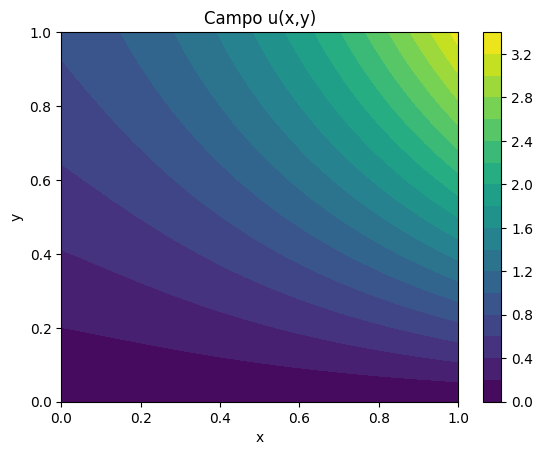

In [19]:
plt.figure()
plt.contourf(X, Y, U, levels=20)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo u(x,y)")
plt.show()

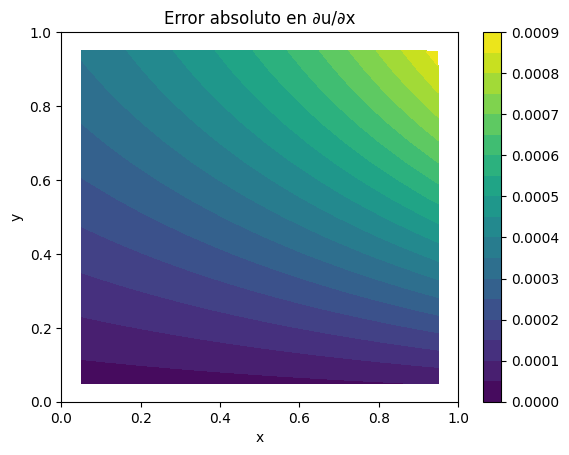

In [20]:
plt.figure()
plt.contourf(X, Y, Err_Ux, levels=20)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Error absoluto en ∂u/∂x")
plt.show()

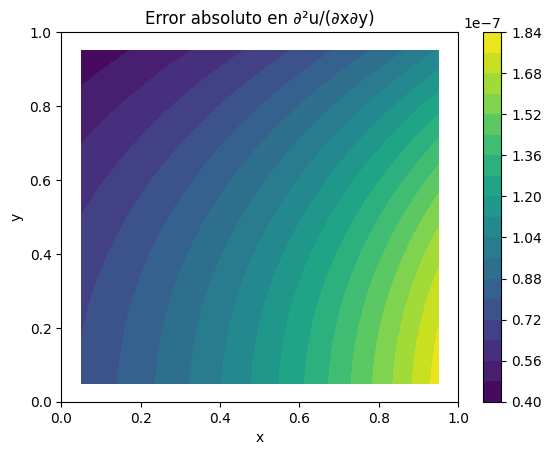

In [21]:
plt.figure()
plt.contourf(X, Y, Err_Uxy, levels=20)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Error absoluto en ∂²u/(∂x∂y)")
plt.show()

# Parte E. Discusión didáctica

## 19. Ideas clave

1. Las derivadas parciales se aproximan de forma análoga a las derivadas ordinarias, pero variando solo una coordenada a la vez.

2. Las fórmulas centradas suelen ofrecer mayor precisión en nodos interiores.

3. Las fórmulas descentradas son especialmente útiles cerca de fronteras del dominio.

4. La derivada mixta requiere información en una vecindad bidimensional del punto.

5. Estas aproximaciones son la base de muchos esquemas numéricos para ecuaciones en derivadas parciales, como:
   - ecuación de Laplace,
   - ecuación de Poisson,
   - ecuación de difusión bidimensional,
   - ecuaciones de convección-difusión.

## 20. Ejercicios sugeridos

1. Repetir el análisis con otra función, por ejemplo:

$$
u(x,y)=\sin(xy)+x^3 y
$$

2. Refinar la malla y estudiar cómo cambia el error máximo interior.

3. Aproximar el Laplaciano:

$$
\nabla^2 u = \frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}
$$

y compararlo con su valor exacto.

4. Implementar fórmulas descentradas en los bordes de la malla.

In [22]:
# Ejemplo opcional: cálculo del Laplaciano exacto y numérico en nodos interiores

Lap_num = Uxx_num + Uyy_num
Lap_ex = Uxx_ex + Uyy_ex
Err_Lap = np.abs(Lap_num - Lap_ex)

print("Error máximo interior en el Laplaciano =", np.nanmax(Err_Lap))

Error máximo interior en el Laplaciano = 0.000876356806512657
